In [1]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import random

from scipy.stats import mannwhitneyu, false_discovery_control, ttest_ind, kstest
from matplotlib.patches import Patch

import cooler 
import cooltools
from matplotlib.colors import LogNorm
import cooltools.lib.plotting
from matplotlib.backends.backend_pdf import PdfPages

from functools import reduce 

%cd /home/varshini/uc_analyses/
import utils, loops_txn, matchmaker_functions
%cd /home/varshini/LoopCall_Analysis_Scripts

import ast
from sklearn import feature_selection
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression



/home/varshini/uc_analyses
/home/varshini/LoopCall_Analysis_Scripts


/home/varshini/microc_analyses/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
# plot formatting
plt.rcParams.update({
    "text.usetex": False})
plt.rcParams['svg.fonttype'] = 'none'
plt.rc('pdf',fonttype = 42)
plt.rcParams["ps.useafm"] = True

plt.rcParams['axes.grid'] = False
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams.update({'font.size': 18})

plt.rcParams["legend.frameon"] = False

In [3]:
datapath = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/matchmaker_scores/'
savedir="/mnt/md0/varshini/Analysis/Blood/figs_v1/figure4"

In [4]:
phases = ['AAVS1_P3', 'NFE2_P3']
dists = [25000, 50000, 100000, 200000]

cooler_path = '/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran'
cooler_names = [os.path.join(cooler_path, f"Sankaran_{p}merged.250.mcool") for p in phases]
LIST_COLS = ['crosser_loop_scores', 'crosser_loop_classes',
            'ss_loop_scores', 'ss_loop_classes']

In [5]:
dist= dists[2]
diff_thresh=10000

In [6]:
nametag = "tf_acrs_sorted_enhancernotpromoternotctcf"
og_mm = pd.read_csv(f"/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/{nametag}_{dist//1000}kb_merge{diff_thresh/1000}kb_clus.bed",
                   sep="\t")
og_mm = og_mm[['chr', 'coord', 'quant']]

In [7]:
# multiple phases
match_scores = matchmaker_functions.load_matchmaker_scores_phase(datapath, phases, nametag = f"nfe2_only_tf", list_cols=LIST_COLS,
                                            dist=dist, difference_threshold=diff_thresh,triangle_score_cols=['triangle_score_P1','triangle_score_P2']).dropna(subset='triangle_score_P1')

match_scores_comp = matchmaker_functions.load_matchmaker_scores_phase(datapath, phases, nametag = f"gfi1b_only_eryth", list_cols=LIST_COLS,
                                            dist=dist, difference_threshold=diff_thresh,triangle_score_cols=['triangle_score_P1','triangle_score_P2']).dropna(subset='triangle_score_P1').sample(1000, random_state=21)


match_scores_control = matchmaker_functions.load_matchmaker_scores_phase(datapath, phases, nametag = f"shuffled_sites", list_cols=LIST_COLS,
                                            dist=dist, difference_threshold=diff_thresh,triangle_score_cols=['triangle_score_P1','triangle_score_P2']).dropna(subset='triangle_score_P1').sample(1000, random_state=12)

In [8]:
match_scores

,chr,coord,perturbation_name,triangle_score_P1,crosser_loop_scores_P1,crosser_loop_classes_P1,crosser_loop_coords_P1,ss_loop_scores_P1,ss_loop_classes_P1,ss_loop_coords_P1,...,crosser_loop_scores_P2,crosser_loop_classes_P2,crosser_loop_coords_P2,ss_loop_scores_P2,ss_loop_classes_P2,ss_loop_coords_P2,agg_crosser_score_P2,agg_ss_score_P2,mean_crosser_score_P2,mean_ss_score_P2
locus,,,,,,,,,,,,,,,,,,,,,
chr1:6317423,chr1,6317423.0,NFE2,1.424136,"[2.4086793870982293, 2.6347728680930915, 6.097...","[P-P, P-CTCF, P-CTCF, P-P, P-CTCF]","[(6236500.5, 6393500.5), (6238500.5, 6343500.5...","[1.355843235772496, 5.671889825626111, 2.71241...","[Null-Null, CTCF-CTCF, P-CTCF, P-P, P-CTCF, P-...","[(6249500.5, 6280500.5), (6347500.5, 6404500.5...",...,"[2.565000947223542, 2.1878555122850103, 6.1060...","[P-P, P-CTCF, P-CTCF, P-P, P-CTCF]","[(6236500.5, 6393500.5), (6238500.5, 6343500.5...","[1.2319300257801211, 6.0696025408026415, 2.741...","[Null-Null, CTCF-CTCF, P-CTCF, P-P, P-CTCF, P-...","[(6249500.5, 6280500.5), (6347500.5, 6404500.5...",19.120310,19.778978,3.824062,3.296496
chr1:9275701,chr1,9275701.5,NFE2,0.903714,[],[],[],[],[],[],...,[],[],[],[],[],[],0.000000,0.000000,NaN,NaN
chr1:10415493,chr1,10415493.5,NFE2,1.252600,"[5.847955839597662, 3.9857051860777433, 1.8559...","[P-CTCF, E-CTCF, P-P, P-P]","[(10377500.5, 10427500.5), (10377500.5, 104945...","[1.3521768641424066, None, None, 5.39117361182...","[P-CTCF, P-Null, E-Null, E-P, P-P, E-P, E-P]","[(10378500.5, 10398500.5), (10388500.5, 103985...",...,"[4.798552385315165, 3.009389944249666, 1.63199...","[P-CTCF, E-CTCF, P-P, P-P]","[(10377500.5, 10427500.5), (10377500.5, 104945...","[1.1131026977927398, None, None, 4.71366338352...","[P-CTCF, P-Null, E-Null, E-P, P-P, E-P, E-P]","[(10378500.5, 10398500.5), (10388500.5, 103985...",10.888428,NaN,2.722107,1.980003
chr1:10459322,chr1,10459322.5,NFE2,1.254360,"[3.9857051860777433, 1.5249911495733304, 5.391...","[E-CTCF, P-P, E-P, P-P]","[(10377500.5, 10494500.5), (10399500.5, 104735...","[5.847955839597662, 1.3521768641424066, 1.9960...","[P-CTCF, P-CTCF, E-CTCF, P-Null, P-P, E-P, E-N...","[(10377500.5, 10427500.5), (10378500.5, 103985...",...,"[3.009389944249666, 1.4484933444703847, 4.7136...","[E-CTCF, P-P, E-P, P-P]","[(10377500.5, 10494500.5), (10399500.5, 104735...","[4.798552385315165, 1.1131026977927398, 1.8237...","[P-CTCF, P-CTCF, E-CTCF, P-Null, P-P, E-P, E-N...","[(10377500.5, 10427500.5), (10378500.5, 103985...",10.890766,NaN,2.722692,1.980977
chr1:12496644,chr1,12496644.5,NFE2,1.371587,[],[],[],[1.7295859450227642],[E-E],"[(12449500.5, 12477500.5)]",...,[],[],[],[1.7838422904805538],[E-E],"[(12449500.5, 12477500.5)]",0.000000,1.783842,NaN,1.783842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chrX:55003094,chrX,55003094.0,NFE2,0.985873,[],[],[],[2.2985223327865496],[E-P],"[(55016500.5, 55027500.5)]",...,[],[],[],[2.5600234176815446],[E-P],"[(55016500.5, 55027500.5)]",0.000000,2.560023,NaN,2.560023
chrX:72532503,chrX,72532503.0,NFE2,0.944656,[],[],[],[],[],[],...,[],[],[],[],[],[],0.000000,0.000000,NaN,NaN
chrX:119427490,chrX,119427490.0,NFE2,1.074473,"[1.9100143939863061, 2.0061763914965294]","[P-P, CTCF-Null]","[(119399500.5, 119468500.5), (119417500.5, 119...","[1.2557127056371773, 2.1099793952016794, 1.920...","[E-P, P-CTCF, CTCF-Null]","[(119469500.5, 119482500.5), (119470500.5, 119...",...,"[1.552149563319417, 1.5984666411850017]","[P-P, CTCF-Null]","[(119399500.5, 119468500.5), (119417500.5, 119...","[1.2915327099944827, 2.2748984032899036, 1.628...","[E-P, P-CTCF, CTCF-Null]","[(119469500.5, 119482500.5), (119470500.5, 119...",3.150616,5.194783,1.575308,1.731594


In [9]:
def do_quant(match_scores, n_quant = 4):
    cleaned_scores = match_scores[[f"triangle_score_P{i}" for i in (range(1, len(phases)+1))]].dropna()
    cleaned_scores = cleaned_scores[(cleaned_scores != 0).all(axis=1)]
    
    grp = matchmaker_functions.do_kmeans(cleaned_scores, n_quant, rand=42)
    cleaned_scores = matchmaker_functions.plot_clusters(cleaned_scores, grp)
    
    inds = cleaned_scores.groupby('g').agg('triangle_score_P1').mean().sort_values().index.tolist()
    ind_dict = dict(zip(inds, np.arange(n_quant)))
    
    cleaned_scores['quant'] = cleaned_scores['g'].map(ind_dict)
    cleaned_scores.drop('g', inplace=True, axis=1)
    
    return cleaned_scores

def merge_match_asof(match_scores_grouped, og_mm, max_diff=10_000):
    chrom_order = [f'chr{i}' for i in range(1, 23)] + ['chrX', 'chrY']

    out = []

    for chrom in chrom_order:

        left = (
            match_scores_grouped[match_scores_grouped['chr'] == chrom]
            .sort_values('coord')
        )

        right = (
            og_mm[og_mm['chr'] == chrom]
            .sort_values('coord')
        )

        if len(left) == 0 or len(right) == 0:
            continue

        merged_chr = pd.merge_asof(
            left,
            right,
            on='coord',
            direction='nearest',
            tolerance=max_diff,
            suffixes=('', '_diff')
        )

        out.append(merged_chr)

    merged = pd.concat(out, ignore_index=True)
    return merged 

                triangle_score_P1  triangle_score_P2  g
locus                                                  
chr2:96617636            1.246415           1.181732  0
chr5:31085054            1.012425           1.111146  0
chr16:15885894           1.109545           1.115475  0
chr16:11233258           1.082423           1.066103  0
chr16:2497453            1.082489           1.098861  0
...                           ...                ... ..
chr21:32516953           1.676330           1.613405  3
chr5:134466851           1.651765           1.553073  3
chr21:33065158           2.072954           2.026677  3
chr5:72227127            1.756815           1.716099  3
chr12:4215521            1.725025           1.760836  3

[875 rows x 3 columns]


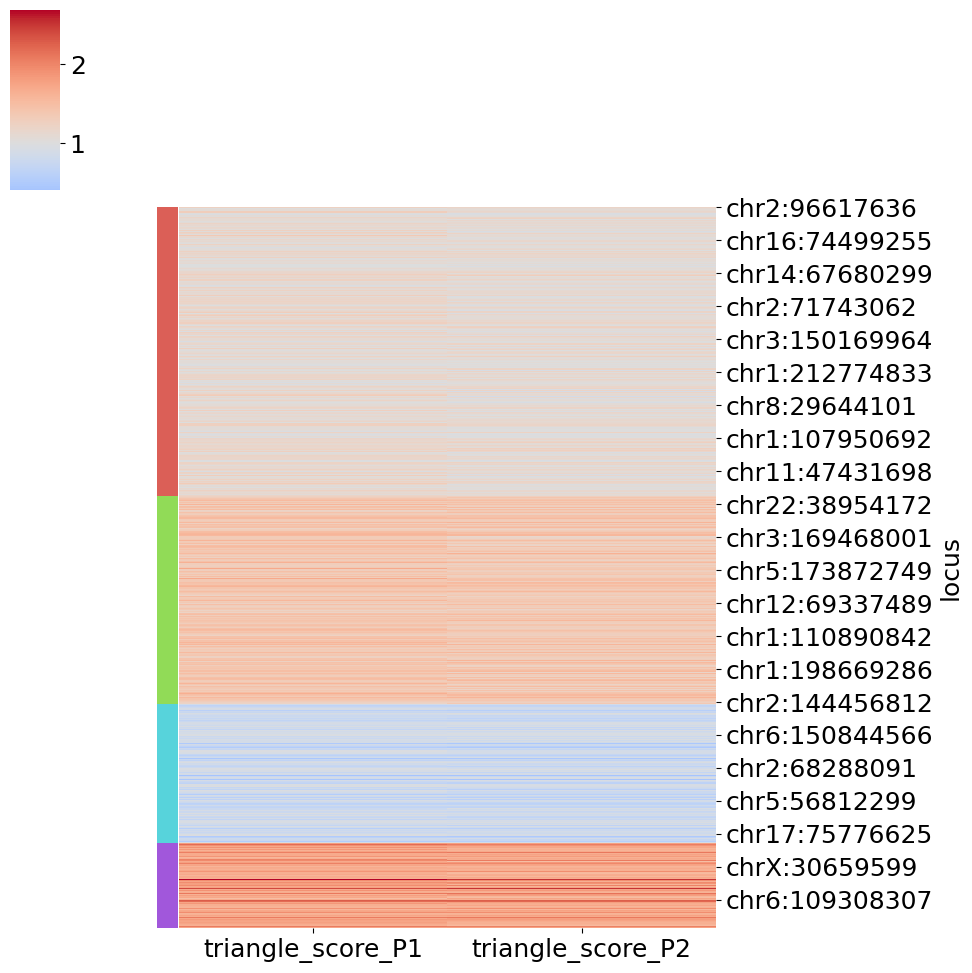

                triangle_score_P1  triangle_score_P2  g
locus                                                  
chr4:144003464           0.877797           0.907482  0
chr3:150726883           0.996650           1.008788  0
chr19:19489388           0.591228           0.563377  0
chr17:50721465           0.759939           0.859551  0
chr8:143529632           0.909048           0.837096  0
...                           ...                ... ..
chr1:161944520           1.636218           1.420812  3
chr5:132664134           1.742267           1.737058  3
chr9:136188260           1.696922           1.750959  3
chr9:100084218           1.538864           1.551095  3
chr13:44388960           1.515862           1.497273  3

[1000 rows x 3 columns]


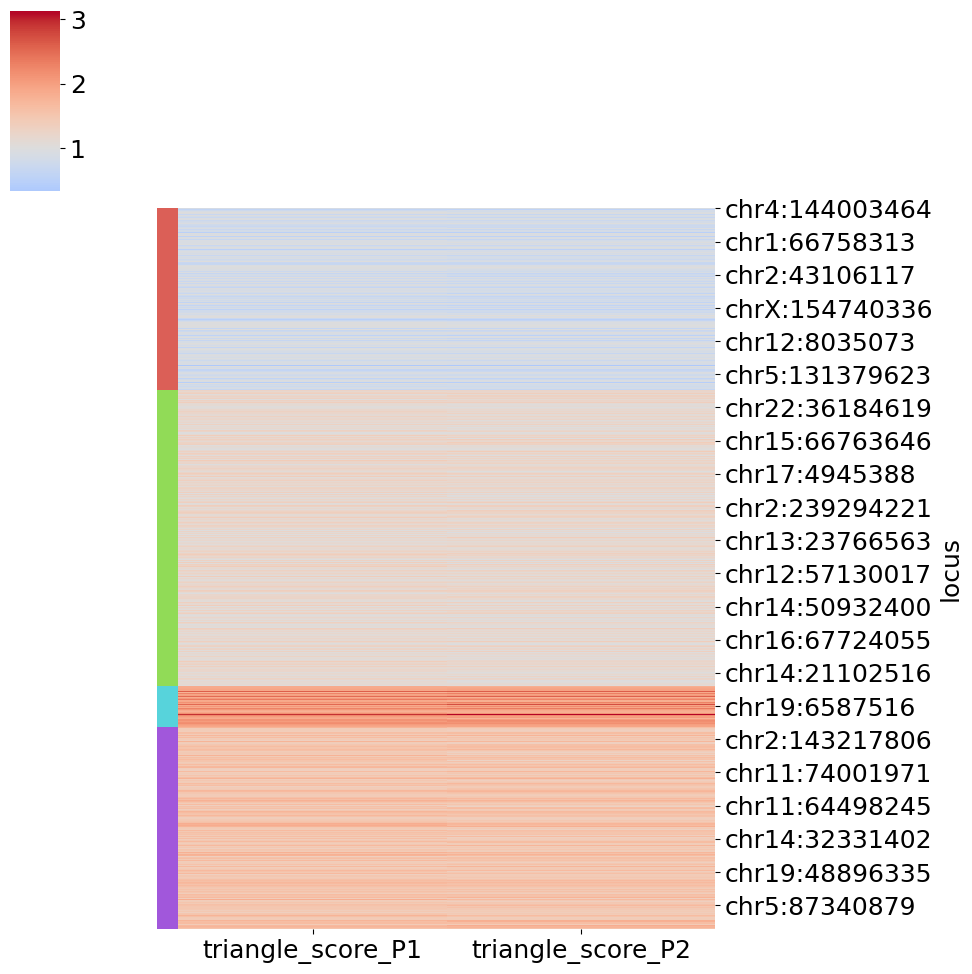

In [10]:
cleaned_scores = do_quant(match_scores)
match_scores_grouped = match_scores.merge(cleaned_scores['quant'], how='inner', left_index=True, right_index=True)

cleaned_scores_comp = do_quant(match_scores_comp)
match_scores_grouped_comp = match_scores_comp.merge(cleaned_scores_comp['quant'], how='inner', left_index=True, right_index=True)


In [11]:
match_scores_grouped

,chr,coord,perturbation_name,triangle_score_P1,crosser_loop_scores_P1,crosser_loop_classes_P1,crosser_loop_coords_P1,ss_loop_scores_P1,ss_loop_classes_P1,ss_loop_coords_P1,...,crosser_loop_classes_P2,crosser_loop_coords_P2,ss_loop_scores_P2,ss_loop_classes_P2,ss_loop_coords_P2,agg_crosser_score_P2,agg_ss_score_P2,mean_crosser_score_P2,mean_ss_score_P2,quant
locus,,,,,,,,,,,,,,,,,,,,,
chr1:6317423,chr1,6317423.0,NFE2,1.424136,"[2.4086793870982293, 2.6347728680930915, 6.097...","[P-P, P-CTCF, P-CTCF, P-P, P-CTCF]","[(6236500.5, 6393500.5), (6238500.5, 6343500.5...","[1.355843235772496, 5.671889825626111, 2.71241...","[Null-Null, CTCF-CTCF, P-CTCF, P-P, P-CTCF, P-...","[(6249500.5, 6280500.5), (6347500.5, 6404500.5...",...,"[P-P, P-CTCF, P-CTCF, P-P, P-CTCF]","[(6236500.5, 6393500.5), (6238500.5, 6343500.5...","[1.2319300257801211, 6.0696025408026415, 2.741...","[Null-Null, CTCF-CTCF, P-CTCF, P-P, P-CTCF, P-...","[(6249500.5, 6280500.5), (6347500.5, 6404500.5...",19.120310,19.778978,3.824062,3.296496,2
chr1:9275701,chr1,9275701.5,NFE2,0.903714,[],[],[],[],[],[],...,[],[],[],[],[],0.000000,0.000000,NaN,NaN,0
chr1:10415493,chr1,10415493.5,NFE2,1.252600,"[5.847955839597662, 3.9857051860777433, 1.8559...","[P-CTCF, E-CTCF, P-P, P-P]","[(10377500.5, 10427500.5), (10377500.5, 104945...","[1.3521768641424066, None, None, 5.39117361182...","[P-CTCF, P-Null, E-Null, E-P, P-P, E-P, E-P]","[(10378500.5, 10398500.5), (10388500.5, 103985...",...,"[P-CTCF, E-CTCF, P-P, P-P]","[(10377500.5, 10427500.5), (10377500.5, 104945...","[1.1131026977927398, None, None, 4.71366338352...","[P-CTCF, P-Null, E-Null, E-P, P-P, E-P, E-P]","[(10378500.5, 10398500.5), (10388500.5, 103985...",10.888428,NaN,2.722107,1.980003,1
chr1:10459322,chr1,10459322.5,NFE2,1.254360,"[3.9857051860777433, 1.5249911495733304, 5.391...","[E-CTCF, P-P, E-P, P-P]","[(10377500.5, 10494500.5), (10399500.5, 104735...","[5.847955839597662, 1.3521768641424066, 1.9960...","[P-CTCF, P-CTCF, E-CTCF, P-Null, P-P, E-P, E-N...","[(10377500.5, 10427500.5), (10378500.5, 103985...",...,"[E-CTCF, P-P, E-P, P-P]","[(10377500.5, 10494500.5), (10399500.5, 104735...","[4.798552385315165, 1.1131026977927398, 1.8237...","[P-CTCF, P-CTCF, E-CTCF, P-Null, P-P, E-P, E-N...","[(10377500.5, 10427500.5), (10378500.5, 103985...",10.890766,NaN,2.722692,1.980977,1
chr1:12496644,chr1,12496644.5,NFE2,1.371587,[],[],[],[1.7295859450227642],[E-E],"[(12449500.5, 12477500.5)]",...,[],[],[1.7838422904805538],[E-E],"[(12449500.5, 12477500.5)]",0.000000,1.783842,NaN,1.783842,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chrX:55003094,chrX,55003094.0,NFE2,0.985873,[],[],[],[2.2985223327865496],[E-P],"[(55016500.5, 55027500.5)]",...,[],[],[2.5600234176815446],[E-P],"[(55016500.5, 55027500.5)]",0.000000,2.560023,NaN,2.560023,1
chrX:72532503,chrX,72532503.0,NFE2,0.944656,[],[],[],[],[],[],...,[],[],[],[],[],0.000000,0.000000,NaN,NaN,0
chrX:119427490,chrX,119427490.0,NFE2,1.074473,"[1.9100143939863061, 2.0061763914965294]","[P-P, CTCF-Null]","[(119399500.5, 119468500.5), (119417500.5, 119...","[1.2557127056371773, 2.1099793952016794, 1.920...","[E-P, P-CTCF, CTCF-Null]","[(119469500.5, 119482500.5), (119470500.5, 119...",...,"[P-P, CTCF-Null]","[(119399500.5, 119468500.5), (119417500.5, 119...","[1.2915327099944827, 2.2748984032899036, 1.628...","[E-P, P-CTCF, CTCF-Null]","[(119469500.5, 119482500.5), (119470500.5, 119...",3.150616,5.194783,1.575308,1.731594,1


In [12]:
merged = merge_match_asof(match_scores_grouped, og_mm)
merged_comp = merge_match_asof(match_scores_grouped_comp, og_mm)

In [13]:
merged

,chr,coord,perturbation_name,triangle_score_P1,crosser_loop_scores_P1,crosser_loop_classes_P1,crosser_loop_coords_P1,ss_loop_scores_P1,ss_loop_classes_P1,ss_loop_coords_P1,...,ss_loop_scores_P2,ss_loop_classes_P2,ss_loop_coords_P2,agg_crosser_score_P2,agg_ss_score_P2,mean_crosser_score_P2,mean_ss_score_P2,quant,chr_diff,quant_diff
0,chr1,6317423.0,NFE2,1.424136,"[2.4086793870982293, 2.6347728680930915, 6.097...","[P-P, P-CTCF, P-CTCF, P-P, P-CTCF]","[(6236500.5, 6393500.5), (6238500.5, 6343500.5...","[1.355843235772496, 5.671889825626111, 2.71241...","[Null-Null, CTCF-CTCF, P-CTCF, P-P, P-CTCF, P-...","[(6249500.5, 6280500.5), (6347500.5, 6404500.5...",...,"[1.2319300257801211, 6.0696025408026415, 2.741...","[Null-Null, CTCF-CTCF, P-CTCF, P-P, P-CTCF, P-...","[(6249500.5, 6280500.5), (6347500.5, 6404500.5...",19.120310,19.778978,3.824062,3.296496,2,chr1,2.0
1,chr1,9275701.5,NFE2,0.903714,[],[],[],[],[],[],...,[],[],[],0.000000,0.000000,NaN,NaN,0,chr1,0.0
2,chr1,10415493.5,NFE2,1.252600,"[5.847955839597662, 3.9857051860777433, 1.8559...","[P-CTCF, E-CTCF, P-P, P-P]","[(10377500.5, 10427500.5), (10377500.5, 104945...","[1.3521768641424066, None, None, 5.39117361182...","[P-CTCF, P-Null, E-Null, E-P, P-P, E-P, E-P]","[(10378500.5, 10398500.5), (10388500.5, 103985...",...,"[1.1131026977927398, None, None, 4.71366338352...","[P-CTCF, P-Null, E-Null, E-P, P-P, E-P, E-P]","[(10378500.5, 10398500.5), (10388500.5, 103985...",10.888428,NaN,2.722107,1.980003,1,chr1,1.0
3,chr1,10459322.5,NFE2,1.254360,"[3.9857051860777433, 1.5249911495733304, 5.391...","[E-CTCF, P-P, E-P, P-P]","[(10377500.5, 10494500.5), (10399500.5, 104735...","[5.847955839597662, 1.3521768641424066, 1.9960...","[P-CTCF, P-CTCF, E-CTCF, P-Null, P-P, E-P, E-N...","[(10377500.5, 10427500.5), (10378500.5, 103985...",...,"[4.798552385315165, 1.1131026977927398, 1.8237...","[P-CTCF, P-CTCF, E-CTCF, P-Null, P-P, E-P, E-N...","[(10377500.5, 10427500.5), (10378500.5, 103985...",10.890766,NaN,2.722692,1.980977,1,chr1,1.0
4,chr1,12496644.5,NFE2,1.371587,[],[],[],[1.7295859450227642],[E-E],"[(12449500.5, 12477500.5)]",...,[1.7838422904805538],[E-E],"[(12449500.5, 12477500.5)]",0.000000,1.783842,NaN,1.783842,2,chr1,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,chrX,55003094.0,NFE2,0.985873,[],[],[],[2.2985223327865496],[E-P],"[(55016500.5, 55027500.5)]",...,[2.5600234176815446],[E-P],"[(55016500.5, 55027500.5)]",0.000000,2.560023,NaN,2.560023,1,chrX,1.0
871,chrX,72532503.0,NFE2,0.944656,[],[],[],[],[],[],...,[],[],[],0.000000,0.000000,NaN,NaN,0,chrX,1.0
872,chrX,119427490.0,NFE2,1.074473,"[1.9100143939863061, 2.0061763914965294]","[P-P, CTCF-Null]","[(119399500.5, 119468500.5), (119417500.5, 119...","[1.2557127056371773, 2.1099793952016794, 1.920...","[E-P, P-CTCF, CTCF-Null]","[(119469500.5, 119482500.5), (119470500.5, 119...",...,"[1.2915327099944827, 2.2748984032899036, 1.628...","[E-P, P-CTCF, CTCF-Null]","[(119469500.5, 119482500.5), (119470500.5, 119...",3.150616,5.194783,1.575308,1.731594,1,chrX,1.0
873,chrX,124698899.0,NFE2,1.305031,[],[],[],[],[],[],...,[],[],[],0.000000,0.000000,NaN,NaN,2,chrX,1.0


In [14]:
nametag

'tf_acrs_sorted_enhancernotpromoternotctcf'

In [15]:
savedir=f"/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/nfe2_only_tf_{dist//1000}kb_merge{diff_thresh/1000}kb_clus.bed"
#merged.to_csv(savedir, sep="\t", index=False)

In [16]:
savedir

'/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/nfe2_only_tf_100kb_merge10.0kb_clus.bed'

In [17]:
savedir=f"/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/nfe2_only_tf_clus.bed"
match_scores_grouped.to_csv(savedir, sep="\t", index=False)

In [18]:
merged[merged['quant_diff'].isna()]

,chr,coord,perturbation_name,triangle_score_P1,crosser_loop_scores_P1,crosser_loop_classes_P1,crosser_loop_coords_P1,ss_loop_scores_P1,ss_loop_classes_P1,ss_loop_coords_P1,...,ss_loop_scores_P2,ss_loop_classes_P2,ss_loop_coords_P2,agg_crosser_score_P2,agg_ss_score_P2,mean_crosser_score_P2,mean_ss_score_P2,quant,chr_diff,quant_diff
28,chr1,61196773.0,NFE2,1.273981,[],[],[],[],[],[],...,[],[],[],0.000000,0.000000,NaN,NaN,2,NaN,NaN
108,chr2,26353053.0,NFE2,1.163222,[2.491468850402822],[E-P],"[(26346500.5, 26412500.5)]",[],[],[],...,[],[],[],1.958698,0.000000,1.958698,NaN,1,NaN,NaN
132,chr2,96148707.5,NFE2,1.262541,"[5.370974314499141, 2.2141799839706717]","[E-P, P-P]","[(96139500.5, 96174500.5), (96145500.5, 962075...",[],[],[],...,[],[],[],6.009688,0.000000,3.004844,NaN,1,NaN,NaN
185,chr3,53236351.5,NFE2,1.095233,[2.4653103618578207],[E-CTCF],"[(53220500.5, 53270500.5)]",[None],[E-P],"[(53258500.5, 53267500.5)]",...,[None],[E-P],"[(53258500.5, 53267500.5)]",1.994631,NaN,1.994631,NaN,1,NaN,NaN
206,chr3,129050482.5,NFE2,1.693420,"[2.1705908531887896, 3.628121883531665, 3.0285...","[E-CTCF, CTCF-Null, CTCF-Null, P-CTCF, E-E]","[(128970500.5, 129052500.5), (128970500.5, 129...","[None, 1.486959606720306]","[E-E, E-P]","[(129055000.5, 129085000.5), (129056500.5, 129...",...,"[None, 1.577487962021729]","[E-E, E-P]","[(129055000.5, 129085000.5), (129056500.5, 129...",13.878040,NaN,2.775608,1.577488,3,NaN,NaN
269,chr5,14865819.0,NFE2,1.082215,[1.9706454167156429],[P-Null],"[(14810500.5, 14871500.5)]",[],[],[],...,[],[],[],1.762452,0.000000,1.762452,NaN,1,NaN,NaN
317,chr6,15091594.5,NFE2,1.529982,[],[],[],[],[],[],...,[],[],[],0.000000,0.000000,NaN,NaN,2,NaN,NaN
332,chr6,42039718.5,NFE2,0.505402,[],[],[],"[3.8390523652243913, None, 1.9302558840962971]","[E-P, E-E, E-CTCF]","[(41940500.5, 42016500.5), (42018500.5, 420285...",...,"[4.160470490562591, None, 2.0601721446916703]","[E-P, E-E, E-CTCF]","[(41940500.5, 42016500.5), (42018500.5, 420285...",0.000000,NaN,NaN,3.110321,0,NaN,NaN
336,chr6,43811273.5,NFE2,1.263945,"[2.3849680401691984, 2.0031939140581194, 2.772...","[E-E, E-E, E-P, E-P]","[(43723500.5, 43839500.5), (43724500.5, 438175...","[2.2162084990246598, 2.726146173120508, 1.6367...","[E-CTCF, E-P, E-E]","[(43724500.5, 43758500.5), (43724500.5, 437715...",...,"[1.988627452268112, 2.616676131842253, 1.42095...","[E-CTCF, E-P, E-E]","[(43724500.5, 43758500.5), (43724500.5, 437715...",9.732462,6.026258,2.433116,2.008753,2,NaN,NaN
355,chr6,139434052.5,NFE2,1.342798,"[2.7016982968414385, 4.342604306224092, 3.9804...","[E-P, E-P, E-P, P-P, E-P, E-P]","[(139374500.5, 139498500.5), (139374500.5, 139...","[2.9004355269911075, 3.5535772040274747, 2.324...","[E-E, E-E, E-E, E-P, E-E]","[(139446500.5, 139518500.5), (139446500.5, 139...",...,"[3.470059064326211, 3.462005036898205, 2.26602...","[E-E, E-E, E-E, E-P, E-E]","[(139446500.5, 139518500.5), (139446500.5, 139...",19.954452,12.666961,3.325742,2.533392,2,NaN,NaN


0.9779375972468598


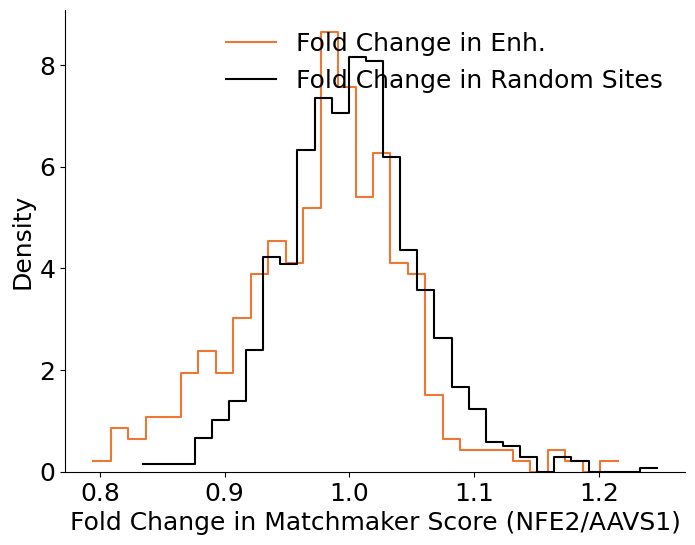

0.9940998700363184


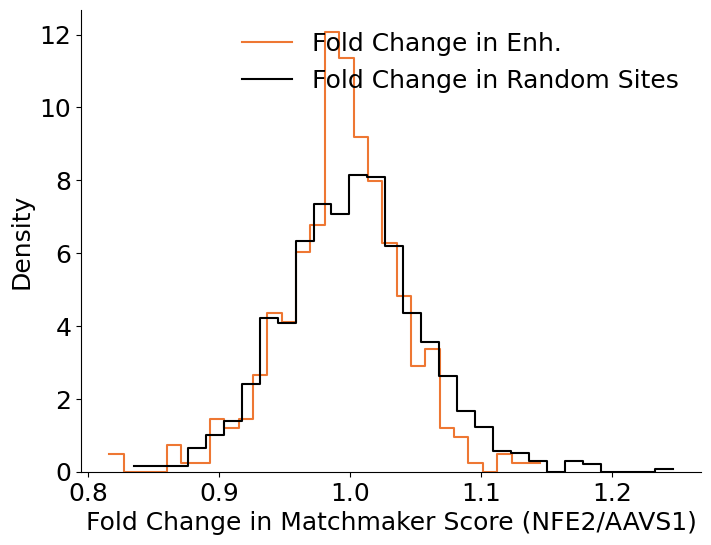

In [19]:
savedir = "/mnt/md0/varshini/Analysis/Blood/figs_v2/supp13/"

## merging analyses 
quants = [2, 3]
test_phase = 'P2'
control_phase = 'P1'
merged_df = matchmaker_functions.merged_attrs(merged[merged['quant_diff'].isin(quants)], test_phase, control_phase)
merged_df_control = matchmaker_functions.merged_attrs(match_scores_control, test_phase, control_phase)

print(merged_df['triangle_fc'].mean())

plt.figure(figsize=(8,6))
sns.histplot(merged_df['triangle_fc'], stat='density', common_norm=False,
                     fill=False, element="step", color='#ee7733',label='Fold Change in Enh.', bins=30)
sns.histplot(merged_df_control['triangle_fc'], stat='density', common_norm=False,
                     fill=False, element="step", color='k', label='Fold Change in Random Sites', bins=30)
plt.xlabel('Fold Change in Matchmaker Score (NFE2/AAVS1)')
plt.ylabel('Density')
plt.legend()
plt.savefig(os.path.join(savedir, "mm_fold_change.svg"))
plt.show()

merged_df_comp = matchmaker_functions.merged_attrs(merged_comp[merged_comp['quant_diff'].isin(quants)], test_phase, control_phase)

print(merged_df_comp['triangle_fc'].mean())

plt.figure(figsize=(8,6))
sns.histplot(merged_df_comp['triangle_fc'], stat='density', common_norm=False,
                     fill=False, element="step", color='#ee7733',label='Fold Change in Enh.', bins=30)
sns.histplot(merged_df_control['triangle_fc'], stat='density', common_norm=False,
                     fill=False, element="step", color='k', label='Fold Change in Random Sites', bins=30)
plt.xlabel('Fold Change in Matchmaker Score (NFE2/AAVS1)')
plt.ylabel('Density')
plt.legend()
plt.savefig(os.path.join(savedir, "mm_fold_change_comp.svg"))
plt.show()

In [24]:
merged_df_comp

,chr,coord,perturbation_name,triangle_score_P1,crosser_loop_scores_P1,crosser_loop_classes_P1,crosser_loop_coords_P1,ss_loop_scores_P1,ss_loop_classes_P1,ss_loop_coords_P1,...,mean_ss_score_P2,quant,chr_diff,quant_diff,triangle_fc,ss_fc,crosser_fc,ss_crosser_ratio_control,ss_crosser_ratio_test,ratio_fc
411,chr7,2955323.0,GFI1B,1.576749,[3.013057663406973],[P-CTCF],"[(2887000.5, 3041000.5)]",[],[],[],...,NaN,2,chr7,2.0,0.815959,NaN,0.584400,NaN,NaN,NaN
313,chr5,96031386.5,GFI1B,1.544924,[2.8171593661348107],[P-P],"[(95961500.5, 96082500.5)]",[2.0883264416991394],[E-P],"[(95933500.5, 95959500.5)]",...,1.643883,2,chr5,2.0,0.825946,0.787177,0.746675,1.349003,1.279593,0.948547
682,chr12,94204917.0,GFI1B,1.579633,"[2.648457480655655, 3.2154371999573867, 2.8388...","[P-Null, P-P, E-P, Null-Null, E-E]","[(94145000.5, 94291000.5), (94149500.5, 942635...",[1.4494054204725109],[E-P],"[(94149500.5, 94174500.5)]",...,1.447491,2,chr12,2.0,0.865434,0.998679,0.776246,8.824559,6.859092,0.777273
66,chr1,161944520.0,GFI1B,1.636218,"[4.487017631270838, 5.183855471194995, 3.48050...","[P-Null, CTCF-Null, E-P]","[(161864500.5, 162024500.5), (161864500.5, 162...",[],[],[],...,NaN,2,chr1,2.0,0.868352,NaN,0.696534,NaN,NaN,NaN
727,chr14,32331402.0,GFI1B,1.614270,[],[],[],[],[],[],...,NaN,2,chr14,2.0,0.870166,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
646,chr12,14273582.5,GFI1B,1.269413,"[3.1483698267215043, 5.380894983836246]","[P-CTCF, E-P]","[(14239500.5, 14366500.5), (14257500.5, 143655...",[],[],[],...,NaN,1,chr12,2.0,1.096542,NaN,1.025841,NaN,NaN,NaN
708,chr13,30504249.5,GFI1B,1.623936,"[3.213806649241724, 2.40216647922434, 3.191384...","[E-CTCF, CTCF-Null, E-P, P-CTCF]","[(30408500.5, 30550500.5), (30454500.5, 305515...","[2.2403409404034536, 1.27038309691487, 1.61071...","[E-P, E-P, P-P]","[(30409000.5, 30461000.5), (30409500.5, 304215...",...,1.560993,2,chr13,3.0,1.112424,0.914388,1.175057,2.193327,2.818588,1.285074
557,chr10,34764854.5,GFI1B,1.244495,[],[],[],[],[],[],...,NaN,1,chr10,2.0,1.121621,NaN,NaN,NaN,NaN,NaN
982,chrX,49691304.5,GFI1B,1.460380,[None],[CTCF-Null],"[(49627500.5, 49754500.5)]",[],[],[],...,NaN,2,chrX,2.0,1.126064,NaN,NaN,NaN,NaN,NaN


In [26]:
from scipy.stats import mannwhitneyu

mannwhitneyu(merged_df['triangle_score_P2'], merged_df['triangle_score_P1'])
mannwhitneyu(merged_df_comp['triangle_score_P2'], merged_df_comp['triangle_score_P1'])

MannwhitneyuResult(statistic=68954.0, pvalue=0.48043724749836303)

In [21]:
# savedir=f"/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/nfe2_tf_only_{dist//1000}kb_merge{diff_thresh/1000}kb_clus.bed"
#match_scores_grouped.to_csv(savedir, sep="\t", index=False)

## Are the most changed flanking scores driven by changes in looping or changes in overall contact frequency?

In [22]:
quants = [0, 1, 2, 3]
test_phase = 'P2'
control_phase = 'P1'
merged_df = matchmaker_functions.merged_attrs(merged[merged['quant_diff'].isin(quants)], test_phase, control_phase)
merged_df_control = matchmaker_functions.merged_attrs(match_scores_control, test_phase, control_phase)

In [23]:
clean_x = merged_df.dropna(subset=['triangle_fc', 'crosser_fc'])['triangle_fc'].values.reshape(-1, 1)
clean_y = merged_df.dropna(subset=['triangle_fc', 'crosser_fc'])['crosser_fc'].values.reshape(-1, 1)
reg_crosser = LinearRegression().fit(clean_x, 
                                     clean_y)
interc = reg_crosser.intercept_
coef = reg_crosser.coef_
pred_y = reg_crosser.predict(clean_x)


clean_x_ss = merged_df.dropna(subset=['triangle_fc', 'ss_fc'])['triangle_fc'].values.reshape(-1, 1)
clean_y_ss = merged_df.dropna(subset=['triangle_fc', 'ss_fc'])['ss_fc'].values.reshape(-1, 1)
reg_ss = LinearRegression().fit(clean_x_ss, 
                                    clean_y_ss )
interc_ss = reg_ss.intercept_
coef_ss = reg_ss.coef_

pred_y_ss = reg_ss.predict(clean_x_ss)

In [24]:
r2_score(clean_y, pred_y)

0.29046868273089443

In [25]:
r2_score(clean_y_ss, pred_y_ss)

0.0013897667858742135

In [28]:
merged_df[['ss_fc','triangle_fc']].dropna()

,ss_fc,triangle_fc
244,0.967303,0.814802
39,0.851997,0.839953
245,0.851349,0.842462
163,1.028286,0.842629
539,0.903794,0.848954
...,...,...
415,0.859128,1.113305
835,0.938525,1.121511
587,1.192472,1.134618
870,1.113769,1.141470


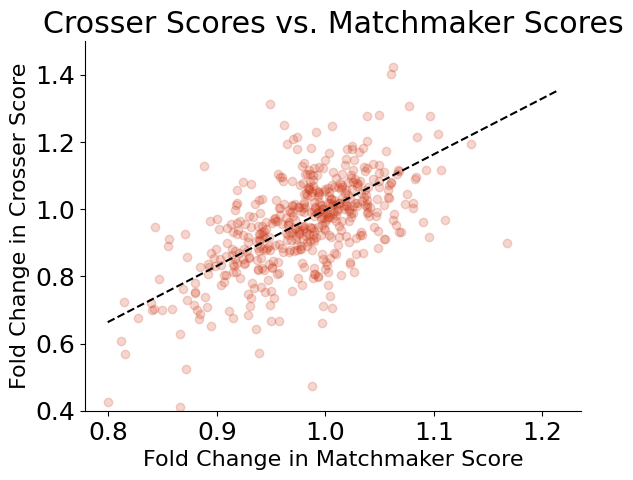

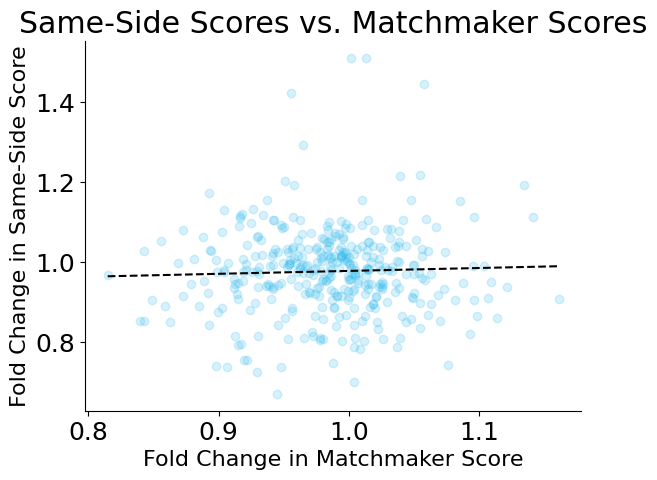

In [55]:


# triangle fc vs ss 
plt.scatter(merged_df['triangle_fc'], merged_df['crosser_fc'], alpha=0.2, color='#CC3311')
plt.xlabel('Fold Change in Matchmaker Score', fontsize=16)
plt.ylabel('Fold Change in Crosser Score', fontsize=16)
plt.plot(clean_x, pred_y, linestyle='--', color='k')
plt.ylim([0.4, 1.5])
#plt.xlim([0.8, 1.2])
plt.title('Crosser Scores vs. Matchmaker Scores')
#plt.savefig(os.path.join(savedir, 'crosser_match_fc_corr.svg'))
plt.show()



plt.scatter(merged_df['triangle_fc'], merged_df['ss_fc'], alpha=0.2, color='#33BBEE')
plt.plot(clean_x_ss, pred_y_ss, linestyle='--', color='k')

plt.xlabel('Fold Change in Matchmaker Score',fontsize=16)
plt.ylabel('Fold Change in Same-Side Score', fontsize=16)
plt.title('Same-Side Scores vs. Matchmaker Scores')
#plt.ylim([0.5, 1.5])
#plt.ylim([0.7, 1.5])
#plt.savefig(os.path.join(savedir, 'ss_match_fc_corr.svg'))
plt.show()